# Resonator flux spectroscopy

In [11]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal05_resonator_flux_spectroscopy import ResonatorFluxSpectroscopy

## Run parameters

In [12]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config   # Flux bias will be restored if not None
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "resonator_flux_spectroscopy"

QUBITS = ["q1"]
FREQUENCY_CENTER = None
FREQUENCY_WIDTH = 5e6
FREQUENCY_POINTS = 101
FLUX_START = 1
FLUX_STOP = -1
FLUX_POINTS = 101
REPETITIONS = 10
FLUX_SETTLE_TIME = 1e-6

READOUT_AMPLITUDE = None
OUTPUT_ATTENUATION = None
INPUT_ATTENUATION = None
READOUT_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True

## Hardware and experiment

In [13]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ResonatorFluxSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)

<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [14]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    flux_start=FLUX_START,
    flux_stop=FLUX_STOP,
    flux_points=FLUX_POINTS,
    repetitions=REPETITIONS,
    flux_settle_time=FLUX_SETTLE_TIME,
    readout_amplitude=READOUT_AMPLITUDE,
    output_attenuation=OUTPUT_ATTENUATION,
    input_attenuation=INPUT_ATTENUATION,
    readout_lo_frequency=READOUT_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

  0%|          | 0/101 [00:00<?, ?step/s]

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
/home/reny871224/mic

<xarray.Dataset> Size: 408kB
Dimensions:           (acq_index_S21_q1: 10201)
Coordinates:
    flux_q1           (acq_index_S21_q1) float64 82kB 1.0 1.0 1.0 ... -1.0 -1.0
    frequency_q1      (acq_index_S21_q1) float64 82kB 6.054e+09 ... 6.059e+09
  * acq_index_S21_q1  (acq_index_S21_q1) int64 82kB 0 1 2 ... 10198 10199 10200
Data variables:
    S21_q1            (acq_index_S21_q1) complex128 163kB (0.0011680329084396...
Attributes:
    tuid:     20260915-142226-475-0e4cb2

## Optional: Simulated data

In [15]:
# dataset = experiment.simulated_data(
#     frequency_center=FREQUENCY_CENTER,
#     frequency_width=FREQUENCY_WIDTH,
#     frequency_points=FREQUENCY_POINTS,
#     flux_start=FLUX_START,
#     flux_stop=FLUX_STOP,
#     flux_points=FLUX_POINTS,
#     maximum_resonance_frequency=None,
#     frequency_shift=10e6,
#     flux_period=1.0,
#     sweet_spot=0.0,
#     loaded_quality_factor=1e4,
#     coupling_quality_factor=1.2e4,
#     noise=0.002,
#     seed=42,
# )

## Analysis

In [16]:
results = experiment.analysis()



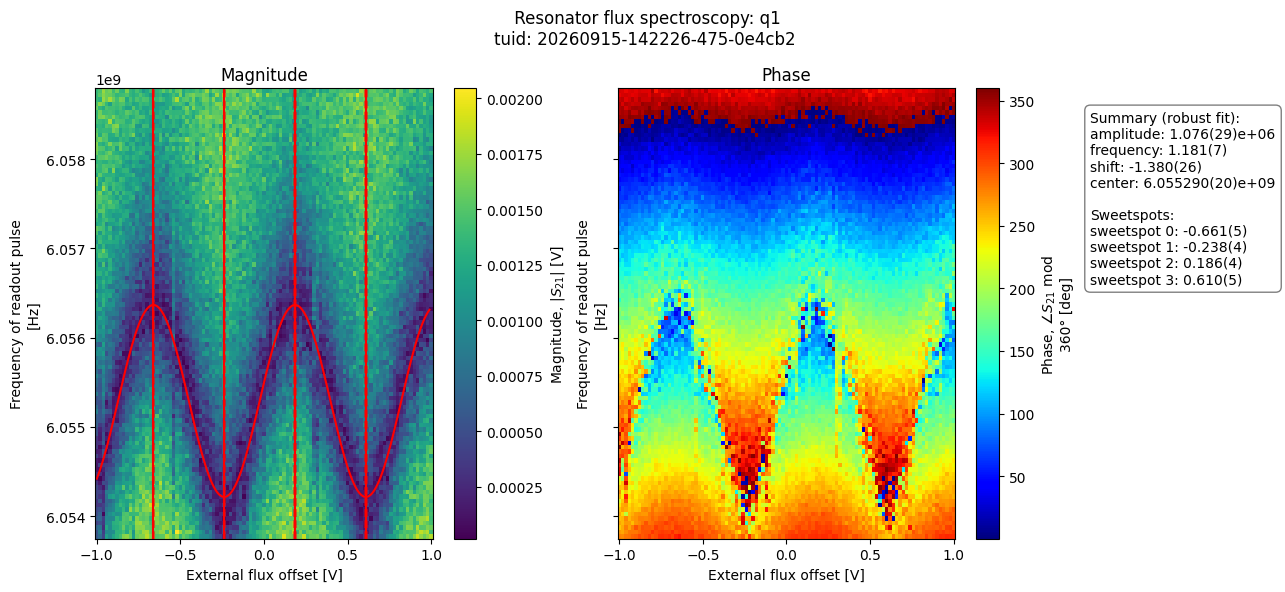

q1: period=0.847042, center=6.055289875 GHz
  candidate 0: -0.661044 V
  candidate 1: -0.237523 V
  candidate 2: 0.185997 V
  candidate 3: 0.609518 V


In [17]:
if PLOT_RESULTS:
    experiment.plot()
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: period={result.flux_period:.6g}, "
            f"center={result.center_frequency / 1e9:.9f} GHz"
        )
        for index, value in enumerate(result.sweet_spots):
            print(f"  candidate {index}: {value:.6f} V")
    else:
        print(f"{qubit}: fit failed")

## Optional: apply and persist a selected operating point

In [18]:
SELECTED_FLUX_BIASES = {"q1":0.185997}   # Set after inspecting the analysis
APPLY_SELECTED_FLUX_BIASES = True
SAVE_SELECTED_FLUX_BIASES = True

UPDATE_READOUT_FREQUENCY = True  # Set clock_freqs.readout from the fitted flux curve (red line)
SAVE_DEVICE_CONFIG = SESSION.device_config  # Use None if persisting is not required

In [19]:
if APPLY_SELECTED_FLUX_BIASES:
    if SELECTED_FLUX_BIASES is None:
        raise ValueError("Set SELECTED_FLUX_BIASES before applying a bias.")

    applied_biases = experiment.apply_flux_biases(SELECTED_FLUX_BIASES)
    for qubit, value in applied_biases.items():
        print(f"{qubit}: live flux bias = {value:.6f} V")

    if SAVE_SELECTED_FLUX_BIASES:
        if FLUX_CONFIG is None:
            raise ValueError("Set FLUX_CONFIG to a file path before saving.")
        saved_path = experiment.save_flux_biases(
            FLUX_CONFIG,
            SELECTED_FLUX_BIASES,
        )
        print(f"Saved flux operating points to {saved_path}")

    if UPDATE_READOUT_FREQUENCY:
        updated_frequencies = experiment.update_readout_frequencies(SELECTED_FLUX_BIASES)
        for qubit, frequency in updated_frequencies.items():
            print(f"{qubit}: readout frequency (from fit) = {frequency / 1e9:.9f} GHz")

        if SAVE_DEVICE_CONFIG is not None:
            saved_device_path = save_device_configuration(
                hardware_agent.quantum_device,
                SAVE_DEVICE_CONFIG,
            )
            print(f"Saved updated device configuration to {saved_device_path}")

q1: live flux bias = 0.185991 V
Saved flux operating points to /home/reny871224/qblox-measurement-nodes/config/flux_config_AS_QRC.json
q1: readout frequency (from fit) = 6.056365978 GHz
Saved updated device configuration to /home/reny871224/qblox-measurement-nodes/config/dut_config_AS_QRC.json


In [20]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [10]:
from qcodes.instrument import Instrument

Instrument.close_all()